# 1. Zadanie 1: Salud 2030

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

## 1.1 EDA

In [9]:
df = pd.read_csv('./data/ObesityDataSet_raw_and_data_sinthetic.csv')
df.head(20)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [25]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Data cleaning

#### Brakujące wartości

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

Nie ma brakujących wartości.

#### Duplikaty

In [22]:
print("liczba duplikatów:")
print(df.duplicated().sum())
df[df.duplicated(keep=False)]

liczba duplikatów:
24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight


In [24]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   str    
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   str    
 5   FAVC                            2087 non-null   str    
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   str    
 9   SMOKE                           2087 non-null   str    
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   str    
 12  FAF                             2087 non-null   fl

### Opis kolumn
| Nazwa kolumny | Opis | Rodzaj danych | Możliwe wartości / Zakres |
|---|---|---|---|
| `Gender` | Płeć | Kategoryczna | Kobieta, Mężczyzna |
| `Age` | Wiek | Numeryczna | Wartość numeryczna |
| `Height` | Wzrost | Numeryczna | Wartość numeryczna (w metrach) |
| `Weight` | Waga | Numeryczna | Wartość numeryczna (w kilogramach) |
| `family_history_with_overweight` | Czy członek rodziny cierpiał lub cierpi na nadwagę? | Kategoryczna (binarna) | Tak, Nie |
| `FAVC` | Czy często spożywasz jedzenie wysokokaloryczne? | Kategoryczna (binarna) | Tak, Nie |
| `FCVC` | Czy zazwyczaj jesz warzywa w swoich posiłkach? | Numeryczna | Nigdy, Czasami, Zawsze (zakodowane numerycznie) |
| `NCP` | Ile głównych posiłków jesz w ciągu dnia? | Numeryczna | Między 1 a 2, Trzy, Więcej niż trzy (zakodowane numerycznie) |
| `CAEC` | Czy jesz cokolwiek pomiędzy posiłkami? | Kategoryczna | Nie, Czasami, Często, Zawsze |
| `SMOKE` | Czy palisz papierosy? | Kategoryczna (binarna) | Tak, Nie |
| `CH2O` | Ile wody wypijasz dziennie? | Numeryczna | Mniej niż litr, Między 1 a 2 litry, Więcej niż 2 litry (zakodowane numerycznie) |
| `SCC` | Czy monitorujesz spożywane codziennie kalorie? | Kategoryczna (binarna) | Tak, Nie |
| `FAF` | Jak często podejmujesz aktywność fizyczną? | Numeryczna | Brak, 1 lub 2 dni, 2 do 4 dni, 4 lub 5 dni (zakodowane numerycznie) |
| `TUE` | Ile czasu spędzasz przed urządzeniami technologicznymi takimi jak telefon, gry wideo, telewizja, komputer i inne? | Numeryczna | 0–2 godziny, 3–5 godzin, Więcej niż 5 godzin (zakodowane numerycznie) |
| `CALC` | Jak często pijesz alkohol? | Kategoryczna | Nie piję, Czasami, Często, Zawsze |
| `MTRANS` | Jakiego środka transportu najczęściej używasz? | Kategoryczna | Samochód, Motocykl, Rower, Transport publiczny, Pieszo |
| `NObeyesdad` (kolumna z etykietą klasy) | Poziom otyłości | Kategoryczna | Niedowaga, Waga prawidłowa, Nadwaga I, Nadwaga II, Otyłość I, Otyłość II, Otyłość III |

Text(0.5, 1.0, 'Rozkład klas')

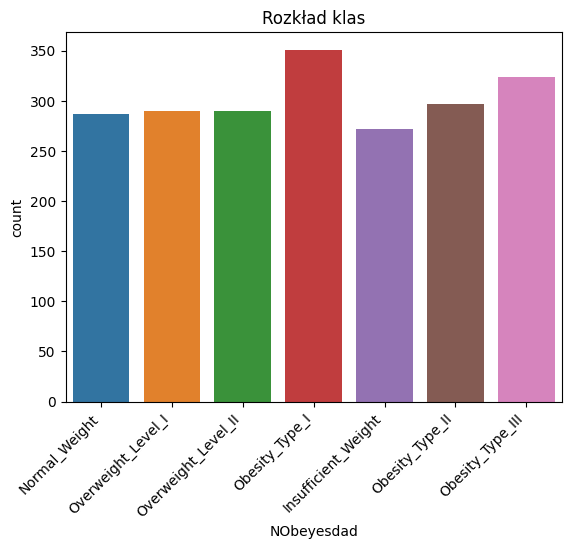

In [18]:
sns.countplot(df, x=df.NObeyesdad, hue='NObeyesdad')
plt.xticks(rotation=45, ha='right')
plt.title('Rozkład klas')

Dane są zrównoważone.

### Rozkład poszczególnych cech

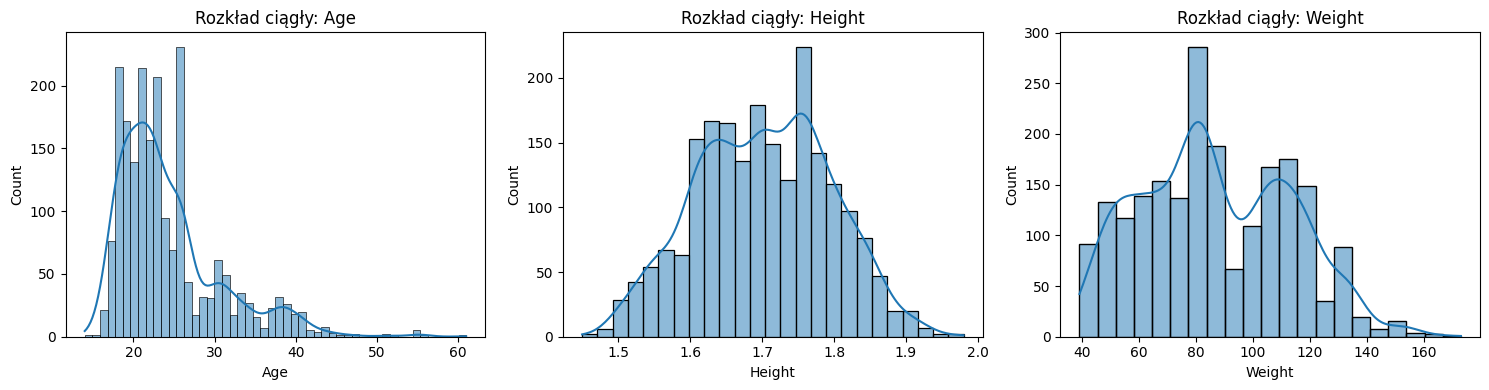

In [33]:
continuous_cols = ['Age', 'Height', 'Weight']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Rozkład ciągły: {col}')

plt.tight_layout()
plt.show()



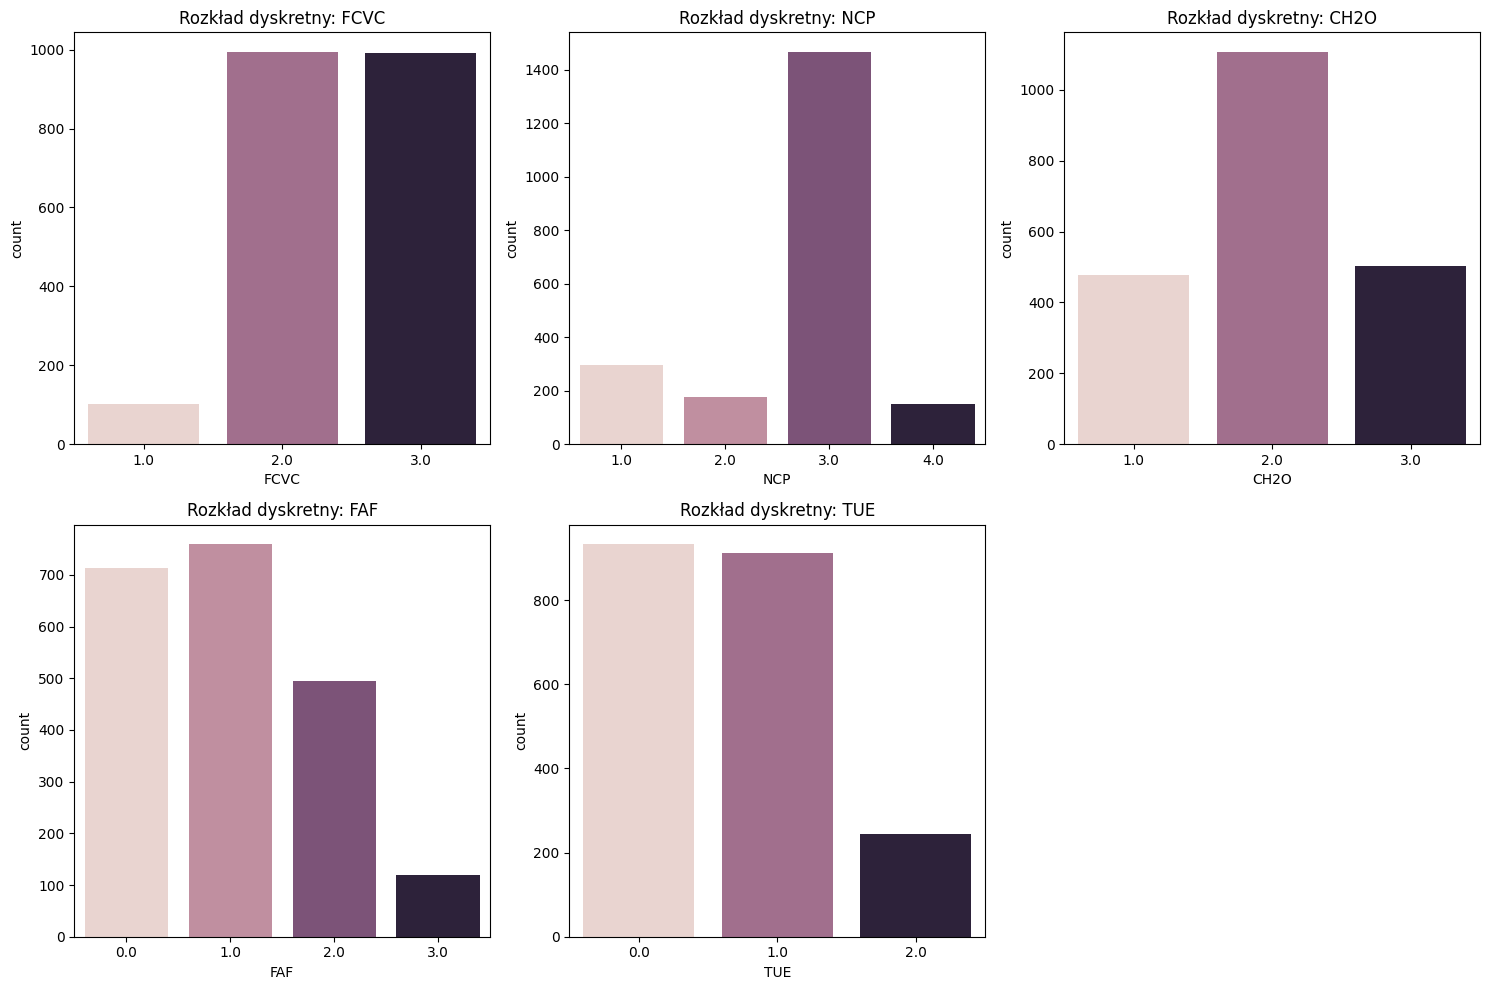

In [34]:
discrete_num_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(discrete_num_cols):
    rounded_data = df[col].round()
    
    sns.countplot(x=rounded_data, ax=axes[i], hue=rounded_data, legend=False)
    axes[i].set_title(f'Rozkład dyskretny: {col}')
    
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

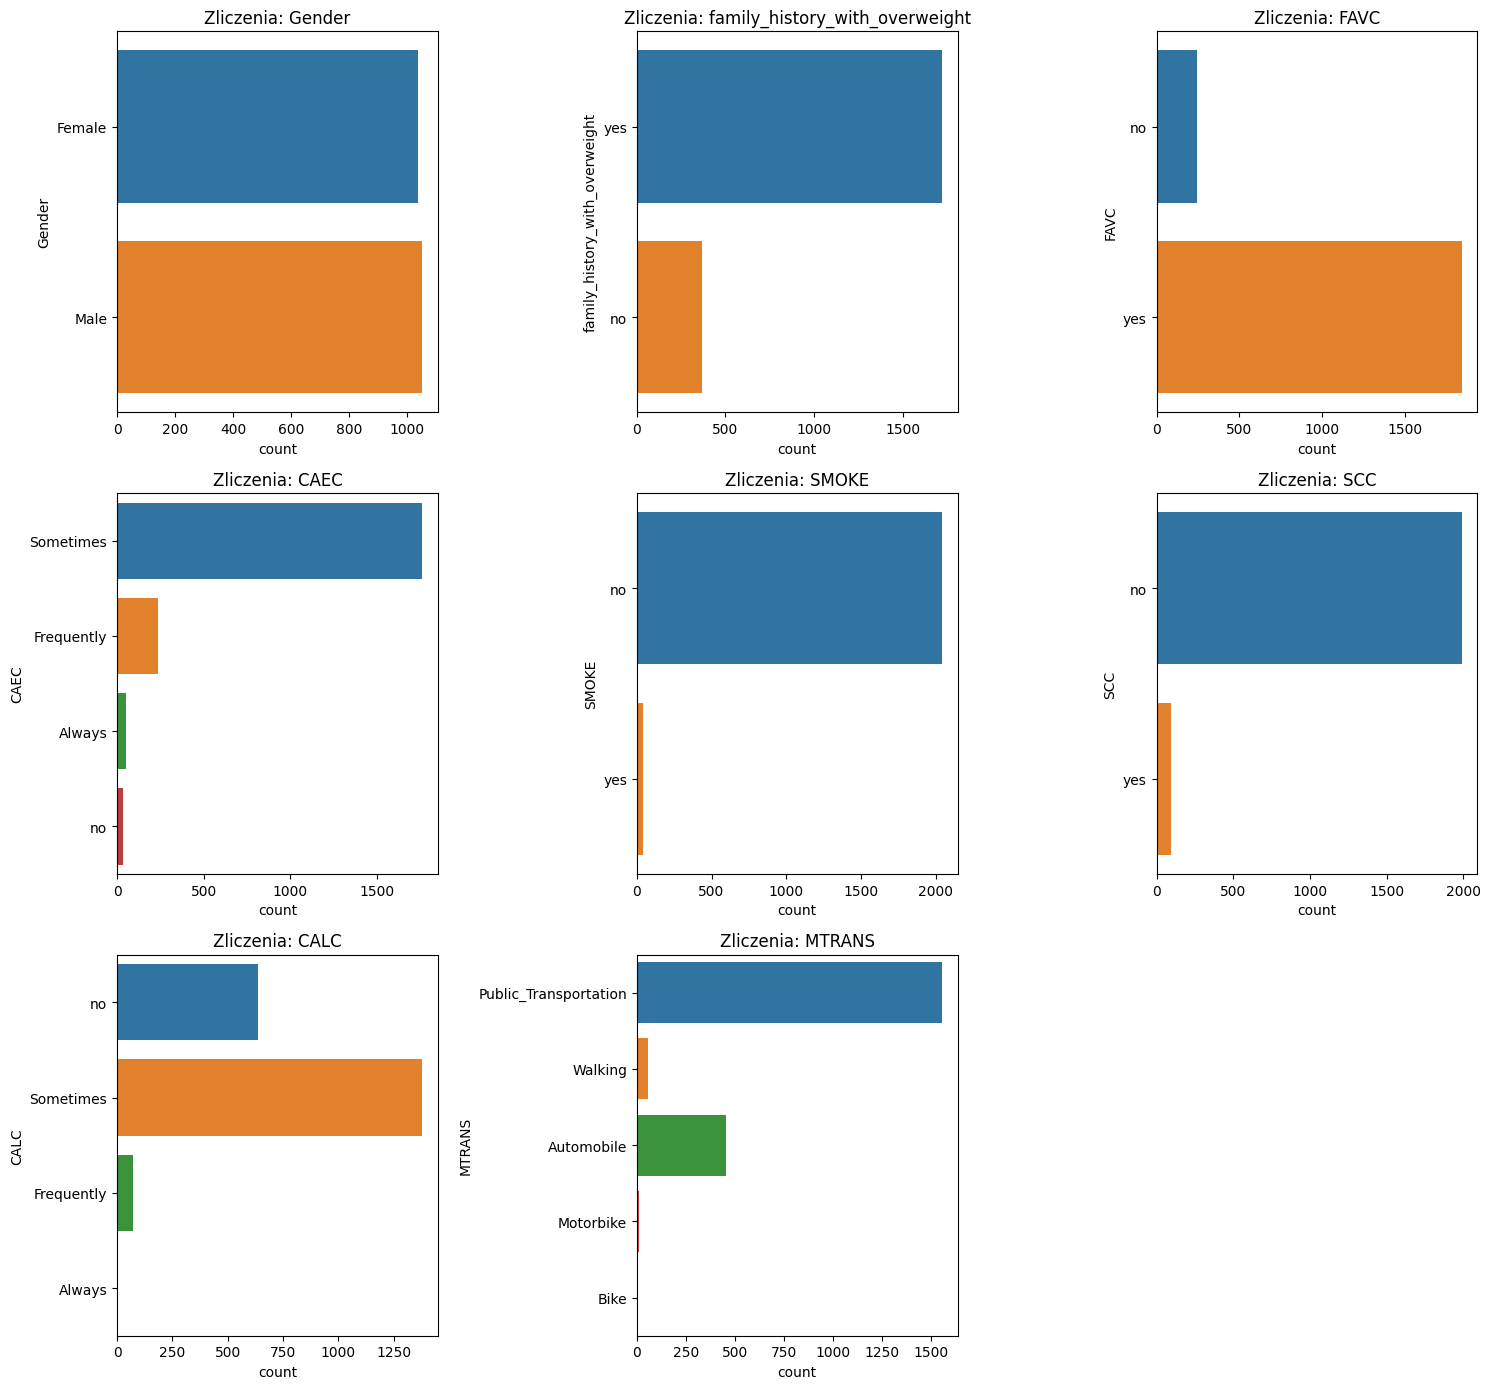

In [35]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Zliczenia: {col}')
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()